# **🚚 Cargo Weight & Balance Optimization Model**
**Objective** : Automate the placement of physical cargo pallets (Unit Load Devices - ULDs) across an aircraft's main and lower decks to ensure total center of gravity (CG) boundaries fall strictly within certified structural flight limits.
**The Math & Architecture** : This is a multi-constrained 3D Bin Packing Problem solved via a hybrid heuristic approach or a Deep Reinforcement Learning (DRL) agent using a Proximal Policy Optimization (PPO) framework. The action space is the coordinate placement grid within the aircraft hold. The reward function penalizes violations of structural constraints and rewards tighter alignment with the target Zero-Fuel Center of Gravity (ZFCG) position:

$$
\text{Reward} = -(\alpha \cdot \vert{}\text{Target CG} - \text{Current CG}\vert{} + \beta \cdot \text{Volume Wastage})
$$

This dataset contains five months of real-world cargo tracking records from a forwarding company's Cargo 2000 system, cleaned up to track how physical goods move through supply chains. By analyzing these messages, the creators reconstructed 3,942 shipping processes—covering nearly 8,000 transport legs—and recorded both the planned and actual durations (in minutes) for each step alongside airport locations. To clean and protect the data, incomplete or canceled shipments were removed, tracking inconsistencies were corrected, and sensitive business details like flight numbers and airport codes were anonymized or removed.

![image.png](attachment:29308750-62b8-4c8a-8e08-7dad84e68cee.png)

## **Dataset Overview: Cargo 2000 (Cargo iQ) Execution Traces**

This dataset tracks freight operational milestones, leg segments, planned vs. actual durations, and airport hops for incoming and outgoing transport legs across global supply chains.

### General Metadata Summary
| Attribute | Value |
| :--- | :--- |
| **Total Observations (Rows)** | `3,943` |
| **Total Features (Columns)** | `98` |
| **Data Types** | `float64` (26 features), `object` (72 features) |
| **Memory Footprint** | `~2.9+ MB` |
| **Missing Values** | 1 record missing across all columns (`3,942` non-null records) |


### Feature Schema Breakdown

The 98 features follow a standardized prefix naming convention depending on the transport leg stage:
* **`i1_`**, **`i2_`**, **`i3_`**: Incoming Transport Legs 1, 2, and 3
* **`o_`**: Outgoing Transport Leg
* **`nr`**: Unique process instance ID (`1` to `3,942`)
* **`legs`**: Total count of incoming legs in the overall process (`1` to `3`)

| Variable Pattern | Field Type / Suffix | Domain / Range | Description |
| :--- | :--- | :--- | :--- |
| **`*_legid`** | Identifier | `[1 ... 14,664]` | Unique identifier for the specific transport leg (includes empty legs). |
| **`*_rcs_p` / `*_rcs_e`** | Planned / Effective | Duration (`mins`) | **Freight Check-in (RCS)**: Planned vs. actual execution duration. |
| **`*_dep_N_p` / `*_dep_N_e`** | Planned / Effective | Duration (`mins`) | **Departure Segment $N$**: Planned vs. actual segment flight duration ($N \in \{1, 2, 3\}$). |
| **`*_dep_N_place`** | Categorical ID | `[100 ... 816]` | **Departure Location**: Masked airport identifier for confidentiality. |
| **`*_rcf_N_p` / `*_rcf_N_e`** | Planned / Effective | Duration (`mins`) | **Arrival Segment $N$ (RCF)**: Planned vs. actual segment arrival duration ($N \in \{1, 2, 3\}$). |
| **`*_rcf_N_place`** | Categorical ID | `[100 ... 816]` | **Arrival Location**: Masked airport identifier for confidentiality. |
| **`*_dlv_p` / `*_dlv_e`** | Planned / Effective | Duration (`mins`) | **Freight Delivery (DLV)**: Planned vs. actual delivery phase duration. |
| **`*_hops`** | Discrete Integer | `[1 ... 4]` | Total number of airport transfer segments/hops in the leg. |

In [1]:
%pip install stable_baselines3 gymnasium



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 5.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
from matplotlib import pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/crawford/cargo-2000-dataset/c2k_data_comma.csv
/kaggle/input/datasets/crawford/cargo-2000-dataset/column_descriptions.txt


In [3]:
data = pd.read_csv('/kaggle/input/datasets/crawford/cargo-2000-dataset/c2k_data_comma.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3943 entries, 0 to 3942
Data columns (total 98 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   nr              3942 non-null   float64
 1   i1_legid        3942 non-null   float64
 2   i1_rcs_p        3942 non-null   float64
 3   i1_rcs_e        3942 non-null   float64
 4   i1_dep_1_p      3942 non-null   float64
 5   i1_dep_1_e      3942 non-null   float64
 6   i1_dep_1_place  3942 non-null   float64
 7   i1_rcf_1_p      3942 non-null   float64
 8   i1_rcf_1_e      3942 non-null   float64
 9   i1_rcf_1_place  3942 non-null   float64
 10  i1_dep_2_p      3942 non-null   object 
 11  i1_dep_2_e      3942 non-null   object 
 12  i1_dep_2_place  3942 non-null   object 
 13  i1_rcf_2_p      3942 non-null   object 
 14  i1_rcf_2_e      3942 non-null   object 
 15  i1_rcf_2_place  3942 non-null   object 
 16  i1_dep_3_p      3942 non-null   object 
 17  i1_dep_3_e      3942 non-null   o

In [4]:
data.isnull().sum()

nr               1
i1_legid         1
i1_rcs_p         1
i1_rcs_e         1
i1_dep_1_p       1
                ..
o_rcf_3_place    1
o_dlv_p          1
o_dlv_e          1
o_hops           1
legs             1
Length: 98, dtype: int64

In [5]:
# 1. Drop the single fully missing/corrupted row if index 3942 is empty
data = data.dropna(subset=['nr']).copy()

# 2. Identify all columns with 'object' dtype (except actual string categorical IDs if any)
object_cols = data.select_dtypes(include=['object']).columns

# 3. Coerce object columns to numeric (invalid strings/question marks will become NaN)
for col in object_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# 4. Fill NaNs resulting from non-existent legs/hops with 0
data = data.fillna(0)

print(f"Cleaned dataset shape: {data.shape}")
print(f"Remaining object columns: {data.select_dtypes(include=['object']).shape[1]}")

Cleaned dataset shape: (3942, 98)
Remaining object columns: 0


In [6]:
# 1. Calculate Delays across Leg 1 (Effective - Planned)
data['i1_checkin_delay'] = data['i1_rcs_e'] - data['i1_rcs_p']
data['i1_flight_delay']  = data['i1_dep_1_e'] - data['i1_dep_1_p']
data['i1_arrival_delay'] = data['i1_rcf_1_e'] - data['i1_rcf_1_p']

# 2. Compute Total Planned Journey Duration (RCS Check-in to Delivery)
data['total_planned_duration'] = data['i1_rcs_p'] + data['i1_dep_1_p'] + data['i1_rcf_1_p'] + data['i1_dlv_p']
data['total_effective_duration'] = data['i1_rcs_e'] + data['i1_dep_1_e'] + data['i1_rcf_1_e'] + data['i1_dlv_e']

# 3. Overall Shipment Schedule Variance
data['total_delay'] = data['total_effective_duration'] - data['total_planned_duration']

# Inspect core delay distribution
data[['i1_checkin_delay', 'i1_flight_delay', 'total_delay']].describe()

,i1_checkin_delay,i1_flight_delay,total_delay
count,3942.000000,3942.000000,3942.000000
mean,-550.210046,505.516996,-1617.561898
std,701.440218,676.887032,5857.942703
min,-9325.000000,-1255.000000,-10207.000000
25%,-780.000000,65.000000,-4035.750000
50%,-344.000000,305.000000,-2993.500000
75%,-108.000000,740.000000,-534.250000
max,1200.000000,9273.000000,86060.000000


In [7]:
# Boeing 777F simplified hold blueprint (longitudinal zones along X-axis)
BOEING_777F_ZONES = {
    "FWD":   {"x_range": (0, 3),  "max_weight_kg": 35_000, "deck": "main"},
    "CENTER":{"x_range": (3, 7),  "max_weight_kg": 45_000, "deck": "main"},
    "AFT":   {"x_range": (7, 10), "max_weight_kg": 35_000, "deck": "main"},
}

GRID_CELL_M = 0.65  # meters per voxel edge (maps IATA ULD dims -> discrete grid)


def meters_to_voxels(length_m, width_m, height_m, grid_shape, cell_m=GRID_CELL_M):
    """Convert physical ULD dimensions (m) into discrete hold voxel units."""
    return (
        max(1, min(grid_shape[0], int(np.ceil(length_m / cell_m)))),
        max(1, min(grid_shape[1], int(np.ceil(width_m / cell_m)))),
        max(1, min(grid_shape[2], int(np.ceil(height_m / cell_m)))),
    )


def generate_cargo_manifest(df_row, seed=None):
    """
    Converts a Cargo 2000 process row into physical Unit Load Devices (ULDs).
    Leg hop counts drive pallet quantity; IATA presets supply realistic dimensions.
    """
    if seed is not None:
        np.random.seed(seed)

    num_legs = int(df_row['legs'])
    manifest = []

    uld_types = [
        {"type": "LD3", "dims": (1.56, 1.53, 1.63), "max_weight": 1588},
        {"type": "PMC Pallet", "dims": (2.44, 3.18, 1.62), "max_weight": 6800},
        {"type": "M1N Box", "dims": (2.44, 3.18, 2.44), "max_weight": 11340},  # width capped for hold fit
    ]

    for leg_idx in range(1, num_legs + 1):
        hops_col = f'i{leg_idx}_hops'
        num_pallets = int(df_row[hops_col]) if hops_col in df_row else 1
        num_pallets = max(1, min(num_pallets, 4))  # cap per leg for sim stability

        for _ in range(num_pallets):
            uld = uld_types[np.random.randint(len(uld_types))]
            weight = np.random.uniform(500, uld['max_weight'])

            manifest.append({
                "process_id": int(df_row['nr']),
                "leg": leg_idx,
                "uld_type": uld['type'],
                "weight_kg": round(weight, 2),
                "length_m": uld['dims'][0],
                "width_m": uld['dims'][1],
                "height_m": uld['dims'][2],
                "volume_m3": round(uld['dims'][0] * uld['dims'][1] * uld['dims'][2], 2),
                "destination_airport": int(df_row[f'i{leg_idx}_rcf_1_place']),
            })

    return pd.DataFrame(manifest)


def manifest_to_cargo_queue(manifest_df, grid_shape, cell_m=GRID_CELL_M, max_items=12):
    """Bridge: manifest DataFrame -> RL environment cargo queue."""
    queue = []
    for _, item in manifest_df.head(max_items).iterrows():
        dims = meters_to_voxels(
            item['length_m'], item['width_m'], item['height_m'], grid_shape, cell_m
        )
        queue.append({
            "weight": float(item['weight_kg']),
            "dims": dims,
            "uld_type": item['uld_type'],
            "leg": int(item['leg']),
        })
    return queue



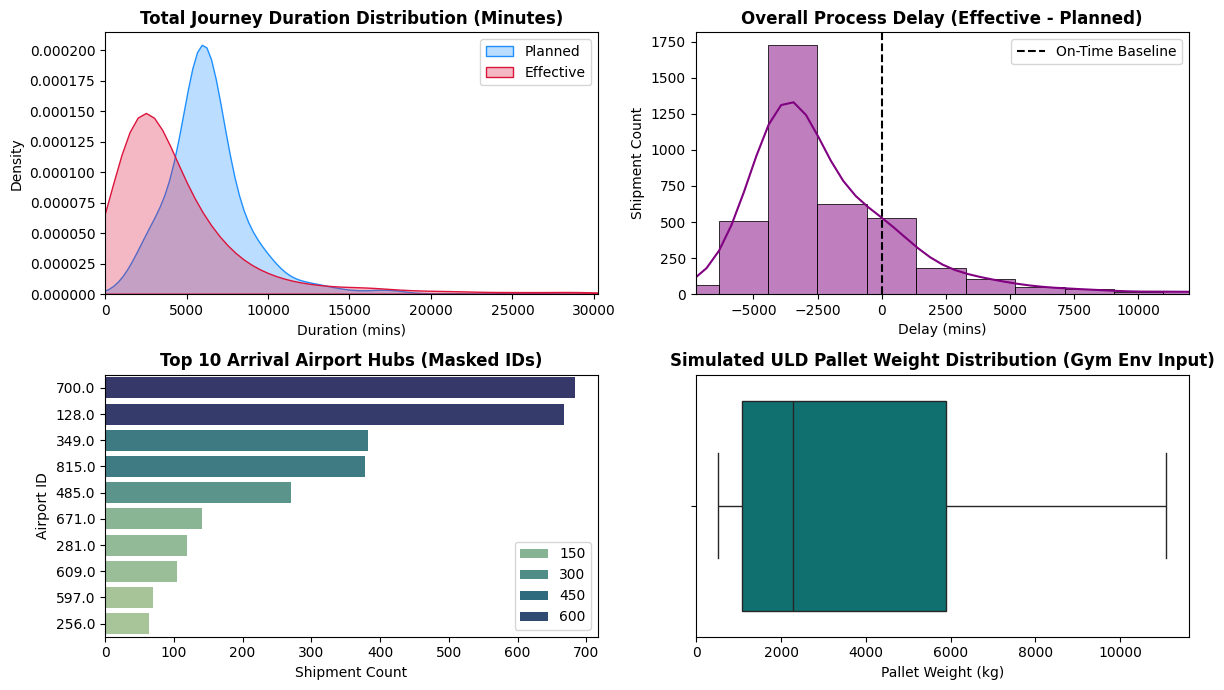


=== Gym Environment Readiness Check ===
Total Process Instances Ready: 3942
Average Legs Per Instance: 2.01
Simulated Average Payload Mass Per Instance: 3640.48 kg


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# Subplot 1: Total Journey Duration Distribution (Planned vs. Effective)
sns.kdeplot(data['total_planned_duration'], ax=axes[0, 0], color='dodgerblue', label='Planned', fill=True, alpha=0.3)
sns.kdeplot(data['total_effective_duration'], ax=axes[0, 0], color='crimson', label='Effective', fill=True, alpha=0.3)
axes[0, 0].set_title("Total Journey Duration Distribution (Minutes)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Duration (mins)")
axes[0, 0].set_ylabel("Density")
axes[0, 0].set_xlim(0, data['total_effective_duration'].quantile(0.98))  # Clip extreme outliers for readability
axes[0, 0].legend()

# Subplot 2: Total Delay Variance Distribution
sns.histplot(data['total_delay'], ax=axes[0, 1], bins=50, color='purple', kde=True)
axes[0, 1].axvline(0, color='black', linestyle='--', linewidth=1.5, label='On-Time Baseline')
axes[0, 1].set_title("Overall Process Delay (Effective - Planned)", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Delay (mins)")
axes[0, 1].set_ylabel("Shipment Count")
axes[0, 1].set_xlim(data['total_delay'].quantile(0.01), data['total_delay'].quantile(0.98))
axes[0, 1].legend()

# Subplot 3: Top 10 Active Arrival Airports
top_airports = data['i1_rcf_1_place'].value_counts().head(10)
sns.barplot(x=top_airports.values, y=top_airports.index.astype(str), ax=axes[1, 0], palette='crest', hue=top_airports.values)
axes[1, 0].set_title("Top 10 Arrival Airport Hubs (Masked IDs)", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Shipment Count")
axes[1, 0].set_ylabel("Airport ID")

# Subplot 4: Manifest Weight Simulation (Sampled across dataset)
# Sample manifests from 100 random rows to verify weight distribution for Gym Env
sample_weights = []
for idx in data.sample(min(100, len(data)), random_state=42).index:
    manifest = generate_cargo_manifest(data.loc[idx])
    sample_weights.extend(manifest['weight_kg'].tolist())

sns.boxplot(x=sample_weights, ax=axes[1, 1], color='teal')
axes[1, 1].set_title("Simulated ULD Pallet Weight Distribution (Gym Env Input)", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Pallet Weight (kg)")

plt.tight_layout()
plt.show()


# 3. Environment Environment Pre-check
print("\n=== Gym Environment Readiness Check ===")
print(f"Total Process Instances Ready: {len(data)}")
print(f"Average Legs Per Instance: {data['legs'].mean():.2f}")
print(f"Simulated Average Payload Mass Per Instance: {np.mean(sample_weights):.2f} kg")
# Manifest -> queue bridge sanity check
sample_row = data.sample(1, random_state=7).iloc[0]
sample_manifest = generate_cargo_manifest(sample_row, seed=7)
sample_queue = manifest_to_cargo_queue(sample_manifest, grid_shape=(10, 4, 3))
print(f"Sample manifest ULDs: {len(sample_manifest)} | Env queue items: {len(sample_queue)}")
print(sample_manifest[['uld_type', 'weight_kg', 'length_m', 'width_m', 'height_m']].head())



In [9]:
import gymnasium as gym
from gymnasium import spaces


class AircraftCargoEnv(gym.Env):
    """
    3D Aircraft Cargo Hold Bin-Packing Environment for Reinforcement Learning.
    Simulates ULD placement and longitudinal CG balancing for a Boeing 777F.
    """

    metadata = {"render_modes": ["human", "ascii"]}

    def __init__(self, data_df, grid_shape=(10, 4, 3), alpha=1.5, beta=0.5,
                 zones=None, max_items_per_episode=12):
        super().__init__()

        self.df = data_df
        self.grid_shape = grid_shape
        self.alpha = alpha
        self.beta = beta
        self.zones = zones or BOEING_777F_ZONES
        self.max_items_per_episode = max_items_per_episode
        self.grid_cell_m = GRID_CELL_M

        self.max_hold_capacity_kg = 103_000.0
        self.target_cg_x = grid_shape[0] / 2.0
        self.cg_fwd_limit = self.target_cg_x - 1.5
        self.cg_aft_limit = self.target_cg_x + 1.5

        self.action_space = spaces.MultiDiscrete(list(grid_shape))

        self.observation_space = spaces.Dict({
            "occupancy_grid": spaces.Box(low=0.0, high=15000.0, shape=grid_shape, dtype=np.float32),
            "current_package": spaces.Box(low=0.0, high=12000.0, shape=(4,), dtype=np.float32),
            "delta_cg": spaces.Box(low=-10.0, high=10.0, shape=(1,), dtype=np.float32),
        })

        # Episode state (initialized in reset)
        self.hold_grid = None
        self.zone_weights = None
        self.cargo_queue = []
        self.current_item_idx = 0
        self.total_mass_kg = 0.0
        self.current_cg_x = self.target_cg_x
        self.step_count = 0
        self.max_steps = 1
        self.episode_stats = {}

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.hold_grid = np.zeros(self.grid_shape, dtype=np.float32)
        self.zone_weights = {name: 0.0 for name in self.zones}
        self.total_mass_kg = 0.0
        self.current_cg_x = self.target_cg_x
        self.step_count = 0
        self.placements_ok = 0
        self.placements_failed = 0

        self.current_instance = self.df.sample(1, random_state=seed).iloc[0]
        self.cargo_queue = self._generate_cargo_queue(self.current_instance)
        self.current_item_idx = 0
        self.max_steps = max(len(self.cargo_queue) * 8, 1)

        return self._get_obs(), {}

    def _generate_cargo_queue(self, row):
        manifest = generate_cargo_manifest(row)
        return manifest_to_cargo_queue(
            manifest, self.grid_shape, self.grid_cell_m, self.max_items_per_episode
        )

    def _zone_for_x(self, x):
        for name, spec in self.zones.items():
            x0, x1 = spec["x_range"]
            if x0 <= x < x1:
                return name
        return "AFT"

    def _zone_overlap_mass(self, x, dx, weight):
        """Attribute placed mass to longitudinal zones by voxel overlap."""
        for xi in range(x, x + dx):
            zone = self._zone_for_x(xi)
            self.zone_weights[zone] += weight / dx

    def _get_obs(self):
        if self.current_item_idx < len(self.cargo_queue):
            item = self.cargo_queue[self.current_item_idx]
            pkg_vec = np.array([item["weight"], *item["dims"]], dtype=np.float32)
        else:
            pkg_vec = np.zeros(4, dtype=np.float32)

        delta_cg = np.array([self.current_cg_x - self.target_cg_x], dtype=np.float32)
        return {
            "occupancy_grid": self.hold_grid.copy(),
            "current_package": pkg_vec,
            "delta_cg": delta_cg,
        }

    def _calculate_cg(self):
        if self.total_mass_kg == 0:
            return self.target_cg_x

        x_indices = np.arange(self.grid_shape[0]).reshape(-1, 1, 1)
        mass_distribution = np.sum(self.hold_grid, axis=(1, 2))
        return float(np.sum(x_indices.flatten() * mass_distribution) / self.total_mass_kg)

    def _can_place(self, x, y, z, dx, dy, dz):
        if (x + dx > self.grid_shape[0] or y + dy > self.grid_shape[1] or z + dz > self.grid_shape[2]):
            return False, "out_of_bounds"
        region = self.hold_grid[x:x + dx, y:y + dy, z:z + dz]
        if np.any(region > 0):
            return False, "collision"
        return True, "ok"

    def _cg_within_envelope(self):
        return self.cg_fwd_limit <= self.current_cg_x <= self.cg_aft_limit

    def _zone_limits_ok(self):
        for name, spec in self.zones.items():
            if self.zone_weights[name] > spec["max_weight_kg"]:
                return False
        return True

    def step(self, action):
        self.step_count += 1
        x, y, z = [int(a) for a in action]

        if self.current_item_idx >= len(self.cargo_queue):
            return self._get_obs(), 0.0, True, False, {"status": "queue_empty"}

        item = self.cargo_queue[self.current_item_idx]
        w, (dx, dy, dz) = item["weight"], item["dims"]

        can_place, reason = self._can_place(x, y, z, dx, dy, dz)
        if not can_place:
            self.placements_failed += 1
            reward = -100.0 if reason == "out_of_bounds" else -75.0
            truncated = self.step_count >= self.max_steps
            terminated = truncated and self.current_item_idx >= len(self.cargo_queue)
            return self._get_obs(), reward, terminated, truncated, {"status": reason}

        self.hold_grid[x:x + dx, y:y + dy, z:z + dz] = w / (dx * dy * dz)
        self.total_mass_kg += w
        self._zone_overlap_mass(x, dx, w)
        self.placements_ok += 1

        self.current_cg_x = self._calculate_cg()
        cg_error = abs(self.target_cg_x - self.current_cg_x)

        occupied_voxels = np.count_nonzero(self.hold_grid)
        total_voxels = int(np.prod(self.grid_shape))
        volume_wastage = (total_voxels - occupied_voxels) / total_voxels

        reward = -(self.alpha * cg_error + self.beta * volume_wastage)

        if not self._cg_within_envelope():
            reward -= 50.0
        if not self._zone_limits_ok():
            reward -= 200.0
        if self.total_mass_kg > self.max_hold_capacity_kg:
            reward -= 500.0

        self.current_item_idx += 1
        terminated = self.current_item_idx >= len(self.cargo_queue)
        truncated = self.step_count >= self.max_steps and not terminated

        info = {
            "cg_offset": cg_error,
            "cg_within_envelope": self._cg_within_envelope(),
            "zone_limits_ok": self._zone_limits_ok(),
            "placements_ok": self.placements_ok,
            "placements_failed": self.placements_failed,
        }
        return self._get_obs(), reward, terminated, truncated, info

    def render(self, mode="ascii"):
        if mode != "ascii":
            return

        top_down = np.sum(self.hold_grid, axis=2)
        print("\n--- Aircraft Deck Load Matrix (Top-Down Density) ---")
        for row in top_down.T:
            line = ""
            for val in row:
                if val == 0:
                    line += "░░ "
                elif val < 150:
                    line += "▒▒ "
                else:
                    line += "██ "
            print(line)

        zone_str = " | ".join(f"{k}: {v:,.0f}kg" for k, v in self.zone_weights.items())
        env_ok = self._cg_within_envelope() and self._zone_limits_ok()
        status = "OK" if env_ok else "WARN"
        print(f"Target CG: {self.target_cg_x:.2f} | Current CG: {self.current_cg_x:.2f} | [{status}]")
        print(f"Zone loads -> {zone_str}\n")


def heuristic_place_action(env):
    """CG-aware first-fit heuristic: scan valid slots, pick lowest CG error."""
    if env.current_item_idx >= len(env.cargo_queue):
        return env.action_space.sample()

    item = env.cargo_queue[env.current_item_idx]
    w, (dx, dy, dz) = item["weight"], item["dims"]

    best_action = None
    best_score = float("inf")

    for x in range(env.grid_shape[0]):
        for y in range(env.grid_shape[1]):
            for z in range(env.grid_shape[2]):
                can_place, _ = env._can_place(x, y, z, dx, dy, dz)
                if not can_place:
                    continue

                # Predict CG if placed at (x, y, z)
                hold = env.hold_grid.copy()
                vol = dx * dy * dz
                hold[x:x + dx, y:y + dy, z:z + dz] = w / vol
                x_idx = np.arange(env.grid_shape[0]).reshape(-1, 1, 1)
                mass_dist = np.sum(hold, axis=(1, 2))
                total = env.total_mass_kg + w
                pred_cg = float(np.sum(x_idx.flatten() * mass_dist) / total)
                cg_error = abs(env.target_cg_x - pred_cg)

                occupied = np.count_nonzero(hold)
                wastage = (hold.size - occupied) / hold.size
                score = env.alpha * cg_error + env.beta * wastage

                if score < best_score:
                    best_score = score
                    best_action = np.array([x, y, z], dtype=int)

    if best_action is None:
        return env.action_space.sample()
    return best_action


def evaluate_policy(env, policy_fn, n_episodes=25, label="policy"):
    """Run episodes and aggregate loader simulator metrics."""
    records = []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=ep)
        done = False
        truncated = False
        total_reward = 0.0
        last_info = {}

        while not (done or truncated):
            action = policy_fn(env, obs)
            obs, reward, done, truncated, info = env.step(action)
            total_reward += reward
            last_info = info

        queue_len = len(env.cargo_queue)
        records.append({
            "episode": ep,
            "policy": label,
            "reward": total_reward,
            "cg_offset": abs(env.current_cg_x - env.target_cg_x),
            "cg_within_envelope": last_info.get("cg_within_envelope", env._cg_within_envelope()),
            "zone_limits_ok": last_info.get("zone_limits_ok", env._zone_limits_ok()),
            "placement_success_rate": env.placements_ok / max(queue_len, 1),
            "placements_ok": env.placements_ok,
            "placements_failed": env.placements_failed,
            "total_mass_kg": env.total_mass_kg,
        })

    return pd.DataFrame(records)



In [10]:
env = AircraftCargoEnv(data_df=data)
obs, info = env.reset(seed=42)

print("Initial Observation Keys:", obs.keys())
print("Cargo queue length:", len(env.cargo_queue))
print("First ULD:", env.cargo_queue[0])

# Heuristic placement smoke test (collision-aware)
action = heuristic_place_action(env)
obs, reward, terminated, truncated, info = env.step(action)
print(f"Heuristic Action: {action} | Reward: {reward:.2f} | Info: {info}")
env.render(mode="ascii")



Initial Observation Keys: dict_keys(['occupancy_grid', 'current_package', 'delta_cg'])
Package Vector Shape: (4,)
Executed Action: [5 3 0] | Step Reward: -100.00

--- Aircraft Deck Load Matrix (Top-Down Density) ---
░░ ░░ ░░ ░░ ░░ ░░ ░░ ░░ ░░ ░░ 
░░ ░░ ░░ ░░ ░░ ░░ ░░ ░░ ░░ ░░ 
░░ ░░ ░░ ░░ ░░ ░░ ░░ ░░ ░░ ░░ 
░░ ░░ ░░ ░░ ░░ ░░ ░░ ░░ ░░ ░░ 
Target CG: 5.00 | Current CG: 5.00



In [11]:
from stable_baselines3 import PPO

env = AircraftCargoEnv(data_df=data)

# --- Baseline: CG-aware heuristic vs random ---
random_metrics = evaluate_policy(env, lambda e, o: e.action_space.sample(), n_episodes=30, label="random")
heuristic_metrics = evaluate_policy(env, lambda e, o: heuristic_place_action(e), n_episodes=30, label="heuristic")

baseline_summary = pd.concat([random_metrics, heuristic_metrics]).groupby("policy").agg(
    mean_reward=("reward", "mean"),
    mean_cg_offset=("cg_offset", "mean"),
    cg_envelope_rate=("cg_within_envelope", "mean"),
    zone_ok_rate=("zone_limits_ok", "mean"),
    placement_success=("placement_success_rate", "mean"),
).round(3)

print("=== Pre-Training Baseline Comparison ===")
display(baseline_summary)

# --- PPO training ---
model = PPO("MultiInputPolicy", env, verbose=1, learning_rate=3e-4)
model.learn(total_timesteps=100_000)



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 6        |
|    ep_rew_mean     | -266     |
| time/              |          |
|    fps             | 525      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 5.9         |
|    ep_rew_mean          | -226        |
| time/                   |             |
|    fps                  | 424         |
|    iterations           | 2           |
|    time_elapsed         | 9           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.016339796 |
|    clip_fraction        | 0.175       |
|    clip_range           | 0.2         |
|    entropy_loss   

In [12]:
model.save("cargo_ppo_model")

def ppo_policy(env, obs):
    action, _ = model.predict(obs, deterministic=True)
    return action

ppo_metrics = evaluate_policy(env, ppo_policy, n_episodes=30, label="ppo")
all_metrics = pd.concat([heuristic_metrics, ppo_metrics])

final_summary = all_metrics.groupby("policy").agg(
    mean_reward=("reward", "mean"),
    mean_cg_offset=("cg_offset", "mean"),
    cg_envelope_rate=("cg_within_envelope", "mean"),
    zone_ok_rate=("zone_limits_ok", "mean"),
    placement_success=("placement_success_rate", "mean"),
).round(3)

print("=== Post-Training Policy Comparison (Heuristic vs PPO) ===")
display(final_summary)

# Visual benchmark
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.boxplot(data=all_metrics, x="policy", y="cg_offset", ax=axes[0], palette="Set2")
axes[0].set_title("CG Offset Distribution")
axes[1].bar(final_summary.index, final_summary["placement_success"], color=["#4C72B0", "#55A868"])
axes[1].set_title("Placement Success Rate")
axes[1].set_ylim(0, 1.05)
axes[2].bar(final_summary.index, final_summary["cg_envelope_rate"], color=["#C44E52", "#8172B2"])
axes[2].set_title("CG Envelope Compliance Rate")
axes[2].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Single-episode qualitative run
obs, _ = env.reset(seed=99)
done = truncated = False
total_reward = 0.0
print("=== PPO Qualitative Load Plan ===")
while not (done or truncated):
    action = ppo_policy(env, obs)
    obs, reward, done, truncated, info = env.step(action)
    total_reward += reward

env.render(mode="ascii")
print(f"Episode reward: {total_reward:.2f}")
print(f"Placements OK/Failed: {env.placements_ok}/{env.placements_failed}")



=== Testing Trained Policy ===

--- Aircraft Deck Load Matrix (Top-Down Density) ---
░░ ░░ ░░ ░░ ░░ ░░ ░░ ░░ ░░ ░░ 
▒▒ ▒▒ ░░ ░░ ░░ ░░ ░░ ░░ ░░ ░░ 
▒▒ ██ ▒▒ ░░ ░░ ░░ ░░ ░░ ░░ ░░ 
░░ ▒▒ ▒▒ ░░ ░░ ░░ ░░ ░░ ░░ ░░ 
Target CG: 5.00 | Current CG: 4.47

Final Episode Reward: -3.24
